# Parameter Tuning Guide

This notebook demonstrates how different parameters affect TMAP visualizations.

## Key Parameters

| Stage | Parameter | Effect |
|-------|-----------|--------|
| MinHash | `num_perm` | Signature accuracy |
| LSHForest | `l` | Index recall |
| Layout | `k`, `kc` | Graph connectivity |
| Layout | `node_size` | Tree spread |
| Layout | `fme_iterations` | Layout smoothness |
| Visualization | `set_edge_style(color, width, opacity)` | Edge visibility and emphasis |

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from tmap import LSHForest, MinHash
from tmap.layout import LayoutConfig, layout_from_lsh_forest

# Create reusable test data
np.random.seed(42)
n_samples = 300
n_bits = 1024

# Create 4 clusters with different patterns
fingerprints = np.zeros((n_samples, n_bits), dtype=np.uint8)
cluster_ids = []

for i in range(n_samples):
    cluster = i % 4
    cluster_ids.append(cluster)
    # Cluster-specific bits
    base = cluster * 200
    bits = np.random.choice(150, 40, replace=False) + base
    fingerprints[i, bits] = 1
    # Random bits
    random_bits = np.random.choice(n_bits, 15, replace=False)
    fingerprints[i, random_bits] = 1

cluster_ids = np.array(cluster_ids)
print(f"Created {n_samples} samples in 4 clusters")


Created 300 samples in 4 clusters


## Helper Function for Visualization

In [ ]:
def compute_and_plot(fingerprints, cluster_ids, cfg, title, ax=None):
    """Compute layout and plot with given config."""
    # MinHash
    mh = MinHash(num_perm=128, seed=42)
    sigs = mh.batch_from_binary_array(fingerprints)

    # LSH Forest
    lsh = LSHForest(d=128, l=64)
    lsh.batch_add(sigs)
    lsh.index()

    # Layout
    x, y, s, t = layout_from_lsh_forest(lsh, cfg)

    # Plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    scatter = ax.scatter(x, y, c=cluster_ids, cmap='tab10', s=20, alpha=0.7)

    # Draw edges (sample for speed)
    for i in range(min(len(s), 100)):
        ax.plot([x[s[i]], x[t[i]]], [y[s[i]], y[t[i]]], 'k-', alpha=0.1, lw=0.5)

    ax.set_title(title)
    ax.set_aspect('equal')
    ax.axis('off')

    n_edges = len(s)
    n_components = len(x) - n_edges
    ax.text(0.02, 0.98, f"Edges: {n_edges}\nComponents: {n_components}",
            transform=ax.transAxes, va='top', fontsize=8)

    return x, y, s, t


## 1. Effect of `k` (Neighbors per Point)

Higher `k` = more connections = better connectivity but denser graph

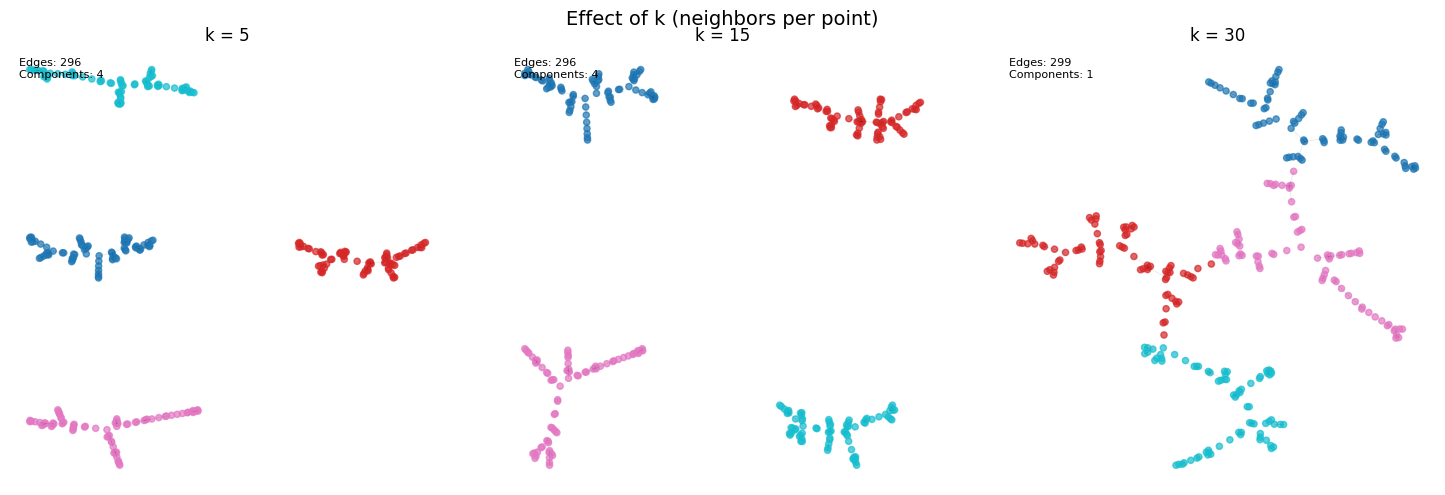

Observation: Higher k improves connectivity (fewer components) but may blur cluster boundaries


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, k in zip(axes, [5, 15, 30]):
    cfg = LayoutConfig()
    cfg.k = k
    cfg.kc = 30
    cfg.deterministic = True
    cfg.seed = 42

    compute_and_plot(fingerprints, cluster_ids, cfg, f"k = {k}", ax)

plt.suptitle("Effect of k (neighbors per point)", fontsize=14)
plt.tight_layout()
plt.show()

print("Observation: Higher k improves connectivity (fewer components) but may blur cluster boundaries")


## 2. Effect of `kc` (Search Quality Multiplier)

Higher `kc` = more candidates searched = better quality neighbors

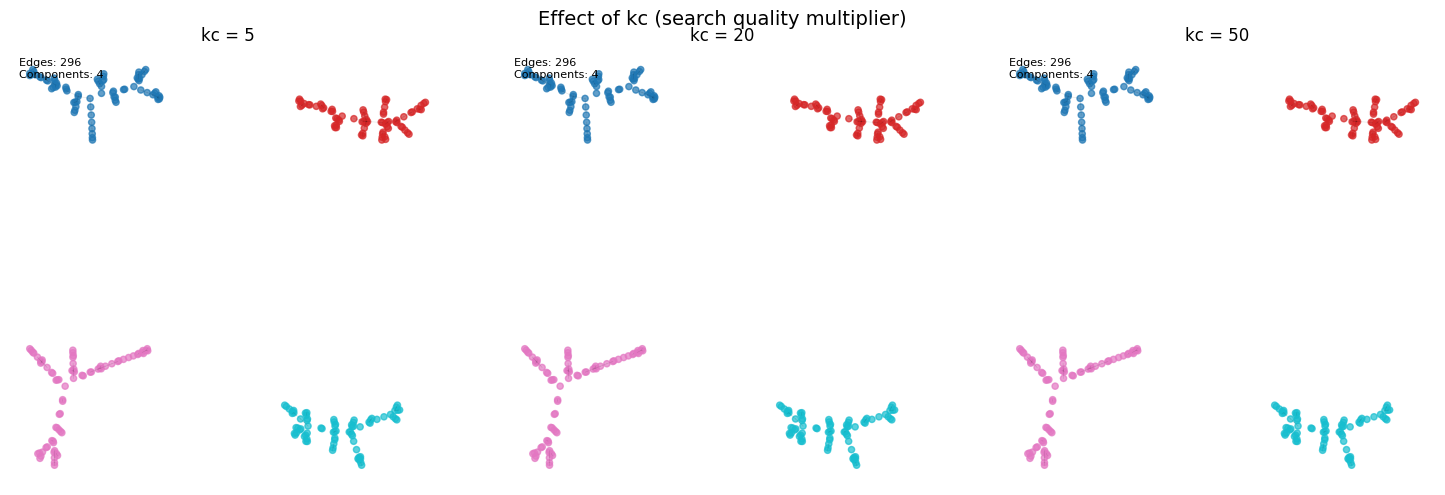

Observation: Higher kc finds better (closer) neighbors, improving cluster separation


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, kc in zip(axes, [5, 20, 50]):
    cfg = LayoutConfig()
    cfg.k = 15
    cfg.kc = kc
    cfg.deterministic = True
    cfg.seed = 42

    compute_and_plot(fingerprints, cluster_ids, cfg, f"kc = {kc}", ax)

plt.suptitle("Effect of kc (search quality multiplier)", fontsize=14)
plt.tight_layout()
plt.show()

print("Observation: Higher kc finds better (closer) neighbors, improving cluster separation")


## 3. Effect of `node_size` (Repulsion Strength)

Higher `node_size` = more repulsion = more spread out tree

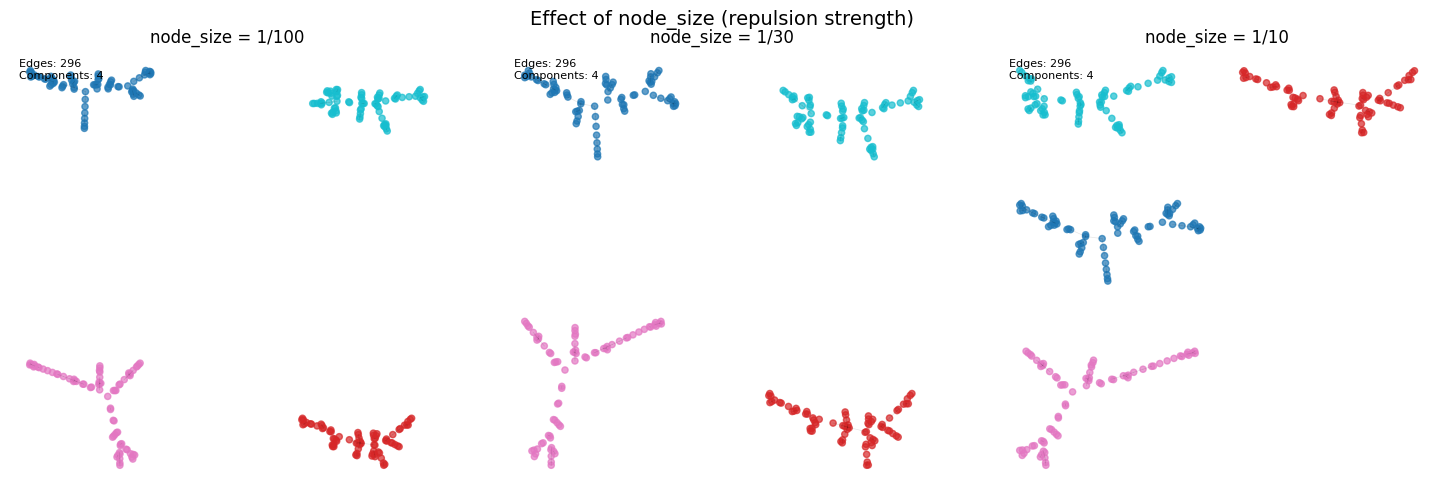

Observation: Larger node_size spreads clusters apart but may create gaps


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, node_size in zip(axes, [1/100, 1/30, 1/10]):
    cfg = LayoutConfig()
    cfg.k = 15
    cfg.kc = 30
    cfg.node_size = node_size
    cfg.deterministic = True
    cfg.seed = 42

    compute_and_plot(fingerprints, cluster_ids, cfg, f"node_size = 1/{int(1/node_size)}", ax)

plt.suptitle("Effect of node_size (repulsion strength)", fontsize=14)
plt.tight_layout()
plt.show()

print("Observation: Larger node_size spreads clusters apart but may create gaps")


## 4. Effect of `fme_iterations` (Layout Smoothness)

More iterations = smoother layout but slower

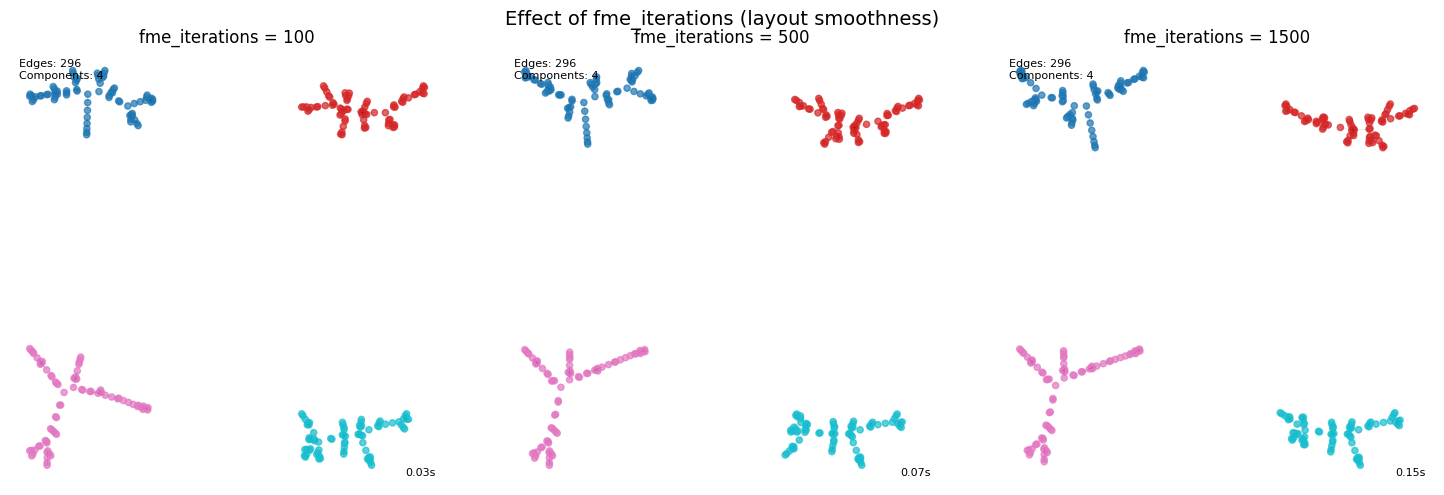

Observation: More iterations = smoother layout but diminishing returns after ~500-1000


In [ ]:
import time

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, iters in zip(axes, [100, 500, 1500]):
    cfg = LayoutConfig()
    cfg.k = 15
    cfg.kc = 30
    cfg.fme_iterations = iters
    cfg.deterministic = True
    cfg.seed = 42

    start = time.time()
    compute_and_plot(fingerprints, cluster_ids, cfg, f"fme_iterations = {iters}", ax)
    elapsed = time.time() - start
    ax.text(0.98, 0.02, f"{elapsed:.2f}s", transform=ax.transAxes, ha='right', fontsize=8)

plt.suptitle("Effect of fme_iterations (layout smoothness)", fontsize=14)
plt.tight_layout()
plt.show()

print("Observation: More iterations = smoother layout but diminishing returns after ~500-1000")


## 5. Effect of LSHForest `l` (Number of Trees)

More trees = better recall = better neighbor quality

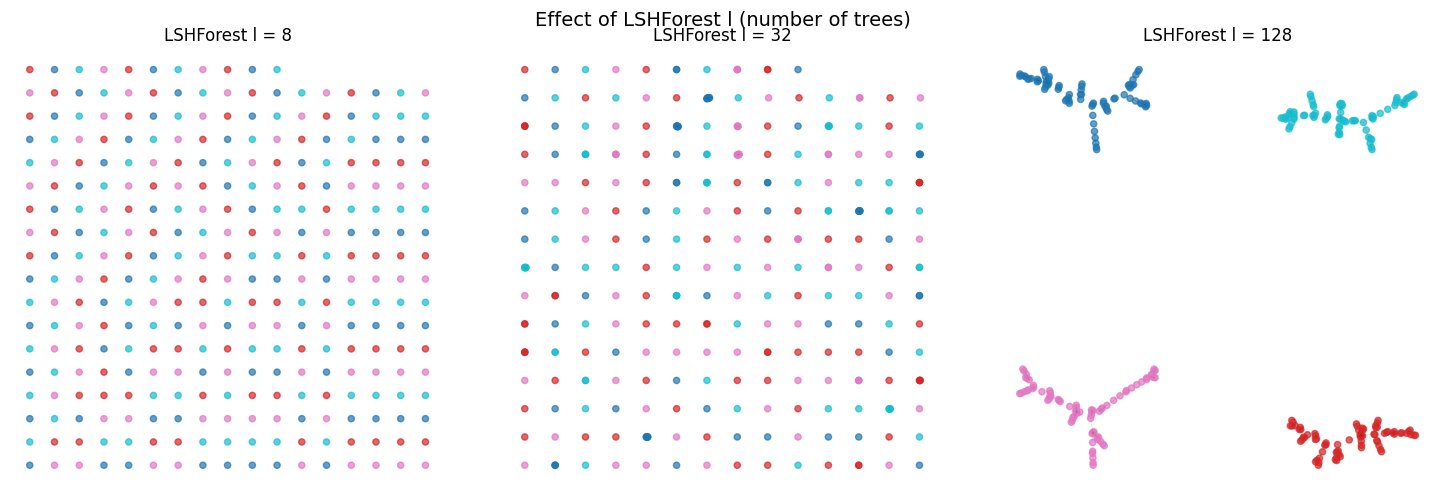

Observation: More trees improves neighbor quality, especially for hard-to-find neighbors


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

mh = MinHash(num_perm=128, seed=42)
sigs = mh.batch_from_binary_array(fingerprints)

for ax, l in zip(axes, [8, 32, 128]):
    # Build LSH Forest with different l
    lsh = LSHForest(d=128, l=l)
    lsh.batch_add(sigs)
    lsh.index()

    cfg = LayoutConfig()
    cfg.k = 15
    cfg.kc = 30
    cfg.deterministic = True
    cfg.seed = 42

    x, y, s, t = layout_from_lsh_forest(lsh, cfg)

    scatter = ax.scatter(x, y, c=cluster_ids, cmap='tab10', s=20, alpha=0.7)
    for i in range(min(len(s), 100)):
        ax.plot([x[s[i]], x[t[i]]], [y[s[i]], y[t[i]]], 'k-', alpha=0.1, lw=0.5)

    ax.set_title(f"LSHForest l = {l}")
    ax.set_aspect('equal')
    ax.axis('off')

plt.suptitle("Effect of LSHForest l (number of trees)", fontsize=14)
plt.tight_layout()
plt.show()

print("Observation: More trees improves neighbor quality, especially for hard-to-find neighbors")


## Recommended Configurations

### Quick Exploration
```python
cfg = LayoutConfig()
cfg.k = 10
cfg.kc = 20
cfg.fme_iterations = 300
```

### Balanced (Default)
```python
cfg = LayoutConfig()
cfg.k = 20
cfg.kc = 50
cfg.fme_iterations = 500
cfg.node_size = 1/30
```

### Publication Quality
```python
cfg = LayoutConfig()
cfg.k = 30
cfg.kc = 100
cfg.fme_iterations = 1000
cfg.mmm_repeats = 2
cfg.node_size = 1/30
cfg.deterministic = True
cfg.seed = 42
```

## Troubleshooting Common Issues

| Problem | Solution |
|---------|----------|
| Disconnected clusters (grid of points) | Increase `k` and `kc` |
| Too compact | Increase `node_size` |
| Too spread out | Decrease `node_size` |
| Layout looks "rough" | Increase `fme_iterations` |
| Clusters not separated | Increase `kc` for better neighbors |
| Different results each run | Set `cfg.deterministic = True` |